# Saturation analysis: GO:BP ORA pathway coverage vs K size

**Environment:** `clamp-analyses`

Loads cached ORA results from `07_saturation_gobp_ora/` (produced by `07_saturation_coverage_gobp_ora.ipynb`) and plots GO:BP ORA pathway coverage (y-axis) against K across sample coverage levels.

Coverage metric: fraction of testable GO:BP terms (~5868, given ARCHS4 gene universe with `minGSSize=10, maxGSSize=500`) covered by at least one LV (FDR < 0.05).

## Load libraries

In [1]:
library(here)
library(ggplot2)
library(dplyr)

source(here("config.R"))

base_output_dir <- config$ARCHS4$DATASET_FOLDER

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Define model grid

In [2]:
k_fracs <- c(0.05, 0.10, 0.25, 0.50, 0.75, 1.00)

pct_to_subdir <- c(
  "1"   = "00_bp_coverage_hall_rs_01",
  "5"   = "01_bp_coverage_hall_rs_05",
  "10"  = "02_bp_coverage_hall_rs_10",
  "25"  = "03_bp_coverage_hall_rs_25",
  "50"  = "04_bp_coverage_hall_rs_50",
  "75"  = "05_bp_coverage_hall_rs_75",
  "100" = "06_bp_coverage_hall_rs_100"
)

get_06_model_dir <- function(pct, seed_idx) {
  file.path(base_output_dir, "06_bp_coverage_rshall",
            pct_to_subdir[as.character(pct)],
            sprintf("hall_coverage_rs%d_seed_%d", pct, seed_idx))
}

K_100    <- readRDS(file.path(get_06_model_dir(100L, 1L), "CLAMP_K.rds"))
k_values <- sort(unique(as.integer(round(k_fracs * K_100))))
message("K_100 = ", K_100, " | k_values = ", paste(k_values, collapse = ", "))

data_coverages <- c(1L, 5L, 10L, 25L)  # expand to c(1L,5L,10L,25L,50L,75L,100L) as jobs complete
seed_indices   <- 1:3

model_grid <- expand.grid(data_pct = data_coverages, k_val = k_values,
                           seed_idx = seed_indices, stringsAsFactors = FALSE)
message("Model grid: ", nrow(model_grid), " combinations")

K_100 = 1728 | k_values = 86, 173, 432, 864, 1296, 1728

Model grid: 72 combinations



## ORA cache directory

In [3]:
ora_cache_dir <- here("output/03_model_biology/00_archs4/00_pathway_coverage/07_saturation_gobp_ora")
dir.create(ora_cache_dir, recursive = TRUE, showWarnings = FALSE)
message("ORA cache dir: ", ora_cache_dir)

ORA cache dir: /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/00_pathway_coverage/07_saturation_gobp_ora



## GO:BP testable denominator

In [4]:
# The testable GO:BP denominator is the union of all unique GO:BP IDs returned by
# enrichGO across all cached ORA results. It is computed in the coverage cell below
# after ORA results are loaded. This is ~5868 terms (not ~30k total GO:BP ontology),
# because enrichGO with minGSSize=10, maxGSSize=500 only tests terms that have enough
# annotated genes in the ARCHS4 gene universe.

## Compute GO:BP coverage from cached ORA results

In [5]:
fdr_cutoff <- 0.001

# Load all cached ORA results
all_cached <- lapply(seq_len(nrow(model_grid)), function(i) {
  cache_path <- file.path(ora_cache_dir,
    sprintf("pct%d_k%d_seed%d.rds",
            model_grid$data_pct[i], model_grid$k_val[i], model_grid$seed_idx[i]))
  if (!file.exists(cache_path)) return(NULL)
  readRDS(cache_path)
})
all_cached <- Filter(Negate(is.null), all_cached)

# Testable denominator: union of GO:BP IDs across all models given ARCHS4 gene universe
n_testable_bp <- length(unique(unlist(lapply(all_cached, function(r) r$ora_df$ID))))
message(sprintf("Testable GO:BP terms (denominator): %d", n_testable_bp))

results <- lapply(seq_len(nrow(model_grid)), function(i) {
  data_pct <- model_grid$data_pct[i]
  k_val    <- model_grid$k_val[i]
  seed_idx <- model_grid$seed_idx[i]

  cache_path <- file.path(ora_cache_dir,
    sprintf("pct%d_k%d_seed%d.rds", data_pct, k_val, seed_idx))

  if (!file.exists(cache_path)) return(NULL)

  res <- readRDS(cache_path)
  sig_terms <- unique(res$ora_df$ID[res$ora_df$p.adjust < fdr_cutoff])

  data.frame(
    data_pct     = data_pct,
    k_val        = k_val,
    seed_idx     = seed_idx,
    n_lvs        = res$n_lvs,
    prop_gobp    = length(sig_terms) / n_testable_bp,
    stringsAsFactors = FALSE
  )
})

results_df <- base::do.call(base::rbind, base::Filter(Negate(is.null), results))
rownames(results_df) <- NULL
results_df <- results_df %>% dplyr::arrange(data_pct, seed_idx, k_val)

message("Loaded ", nrow(results_df), " combinations")
print(results_df)

Testable GO:BP terms (denominator): 5879

Loaded 28 combinations



   data_pct k_val seed_idx n_lvs prop_gobp
1         1    86        1    86 0.4526280
2         1   173        1   173 0.5269604
3         1   432        1   432 0.6235754
4         1   864        1   864 0.6858309
5         1  1296        1  1296 0.6858309
6         5    86        1    86 0.4562000
7         5   173        1   173 0.5050179
8         5   432        1   432 0.6103079
9         5   864        1   864 0.6836197
10        5  1296        1  1296 0.7263140
11        5  1728        1  1728 0.7603334
12        5    86        2    86 0.4468447
13        5   173        2   173 0.5397176
14        5   432        2   432 0.6400748
15        5   864        2   864 0.7014798
16       10    86        1    86 0.4652152
17       10   173        1   173 0.5322334
18       10   432        1   432 0.6196632
19       10   864        1   864 0.6848103
20       10  1296        1  1296 0.7337983
21       10  1728        1  1728 0.7482565
22       10    86        2    86 0.4442932
23       10

## Plot: GO:BP coverage vs K (saturation curves)

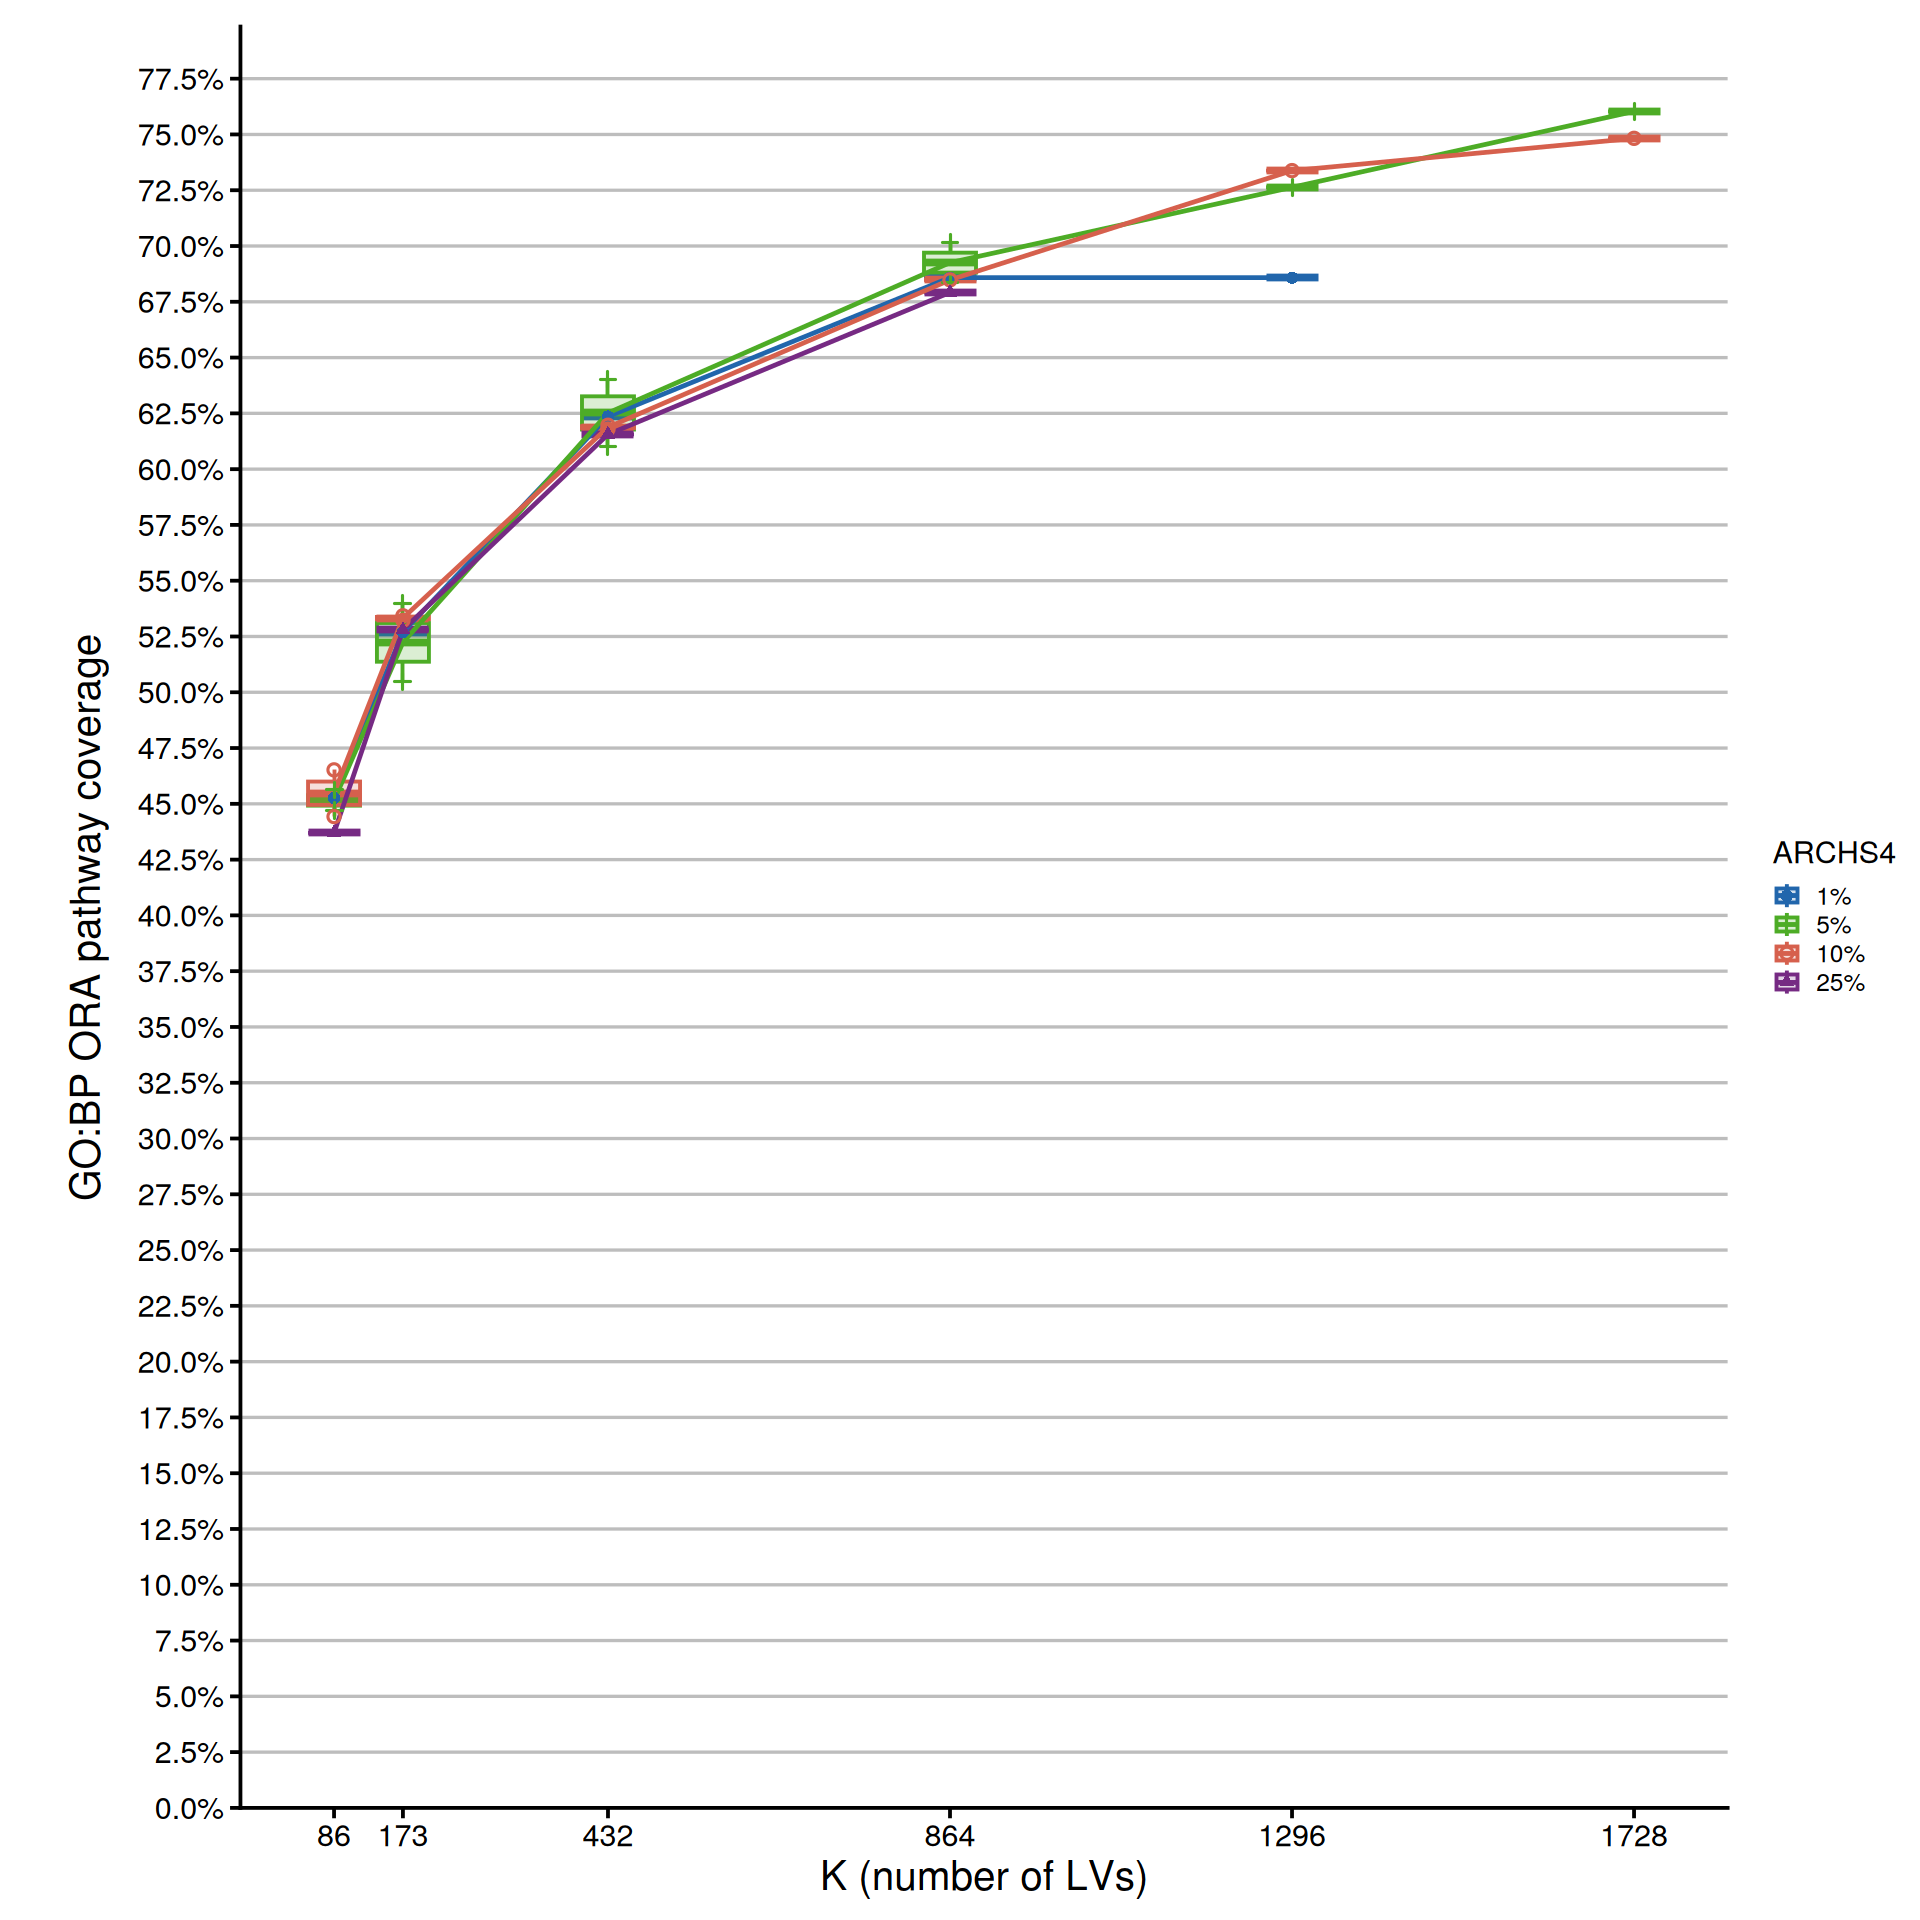

In [6]:
options(repr.plot.width = 16, repr.plot.height = 16)

coverage_colors <- c(
  "1%"   = "#2166AC",
  "5%"   = "#4DAC26",
  "10%"  = "#D6604D",
  "25%"  = "#762A83",
  "50%"  = "#E08214",
  "75%"  = "#01665E",
  "100%" = "#000000"
)
coverage_shapes <- c("1%"=16, "5%"=3, "10%"=1, "25%"=17, "50%"=15, "75%"=8, "100%"=18)

avail_levels <- paste0(sort(unique(results_df$data_pct)), "%")

plot_df <- results_df %>%
  dplyr::mutate(data_label = factor(paste0(data_pct, "%"),
                                    levels = paste0(c(1, 5, 10, 25, 50, 75, 100), "%")))

line_df <- plot_df %>%
  dplyr::group_by(data_pct, k_val, data_label) %>%
  dplyr::summarise(y = median(prop_gobp), .groups = "drop") %>%
  dplyr::arrange(data_label, k_val)

box_width <- diff(range(k_values)) * 0.04

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title        = element_text(size = 24, colour = "black"),
      axis.title.y      = element_text(margin = margin(r = 18)),
      axis.text         = element_text(size = 18, colour = "black"),
      axis.line         = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks        = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor   = element_blank(),
      legend.position    = "right",
      strip.background   = element_blank(),
      strip.text         = element_text(face = "bold", size = 18),
      plot.margin        = margin(t = 16, r = 12, b = 12, l = 42)
    )
}

p <- ggplot(plot_df, aes(x = k_val, y = prop_gobp,
                          colour = data_label, fill = data_label)) +
  geom_boxplot(aes(group = interaction(data_label, factor(k_val))),
               alpha = 0.2, outlier.shape = NA, width = box_width,
               position = "identity") +
  geom_line(data = line_df,
            aes(x = k_val, y = y, group = data_label), linewidth = 1.0) +
  geom_point(aes(shape = data_label), size = 2.5, stroke = 1.0) +
  scale_x_continuous(breaks = k_values) +
  scale_colour_manual(values = coverage_colors, name = "ARCHS4",
                      limits = avail_levels) +
  scale_fill_manual(values   = coverage_colors, name = "ARCHS4",
                    limits = avail_levels) +
  scale_shape_manual(values  = coverage_shapes, name = "ARCHS4",
                     limits = avail_levels) +
  scale_y_continuous(labels  = scales::percent_format(accuracy = 0.1),
                     breaks  = seq(0, 1, by = 0.025),
                     limits  = c(0, NA),
                     expand  = expansion(mult = c(0, 0.05))) +
  labs(x = "K (number of LVs)", y = "GO:BP ORA pathway coverage") +
  theme_ng()

p